# makemore: character-level MLP

Building on the bigram model: instead of only conditioning on the single previous character, this predicts the next character from the previous `block_size` characters, using a small neural net (embedding table → hidden layer → output layer) in place of a lookup table of counts.

In [756]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## Load the names

Each line of `names.txt` is one training example (a first name).

In [757]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [758]:
len(words)

32033

## Build the character vocabulary

Map every character that appears in the dataset (plus a special `.` token marking start/end-of-name) to an integer id, and back. `stoi`/`itos` are used everywhere below to convert between characters and the integer ids the model actually operates on.

In [759]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## Build the training examples

Slide a `block_size`-character window across each name to produce `(context, next_char)` pairs, wrapped in `build_dataset()` so it can run over any subset of `words`. Names are shuffled and split 80/10/10 into train/dev/test *before* windowing, so no single name's characters leak across splits. `Xtr/Xdev/Xte` hold the integer-id contexts; `Ytr/Ydev/Yte` hold the integer id of the character that follows each context.

In [760]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)

# partition train, dev and test sets
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


![Architecture](makemore_mlp_arch.png)

## Model parameters

Define the network as three learned pieces, tied together by the shape rules noted in the comments below (`C` must match `vocab_size`, `W1`'s input side must match `block_size * embbed_d`, `W2`'s output side must match `vocab_size`):
- `C`: the embedding table — one learned vector per character.
- `W1, b1`: the hidden layer — mixes a flattened context's embeddings into `n_hidden` features, followed by a `tanh` nonlinearity (applied in the training loop below).
- `W2, b2`: the output layer — turns those hidden features into one logit (unnormalized score) per possible next character.

Everything here starts as random noise (`torch.randn`)

In [761]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility

# embedding matrix

# instead of building our own statistic table
# we let the C and weight layers train on them

vocab_size = len(itos) # 26 + 1, cannot change
embbed_d = 10 # embedded space dim
block_size = block_size # context length
n_hidden = 100 # neurons per layer

# three rules across layers
# 1) C.shape[0] == vocab_size
# 2) W1.shape[0] == block_size * n_embd
# 3) W2.shape[1] == vocab_size 

# C takes vocab so must match input dim
C = torch.randn((vocab_size, embbed_d), generator=g)

W1 = torch.randn((block_size*embbed_d, n_hidden), generator=g)

b1 = torch.randn(n_hidden, generator=g)

W2 = torch.randn((n_hidden, vocab_size), generator=g)

b2 = torch.randn(vocab_size, generator=g)

# total parameter size
parameters = [C, W1, b1, W2, b2]

In [762]:
# vector embedded database shape
C.shape

torch.Size([27, 10])

In [763]:
sum(p.nelement() for p in parameters) # number of parameters in total

6097

## Enable gradients

`C, W1, b1, W2, b2` are plain tensors until this runs — `requires_grad = True` enables backward()

In [764]:
for p in parameters:
  p.requires_grad = True

## Training setup

`lre`/`lrs` is a log-spaced sweep of candidate learning rates (`1e-3` to `1e0`) for an LR-finder-style experiment — swap the commented-out `#lr = lrs[i]` line back in inside the training loop to use it instead of the fixed schedule. `lri`/`lossi`/`stepi` are just the trackers the training loop below appends to.

In [765]:
# learning rate problem
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [766]:
lri = []
lossi = []
stepi = []

## Train

Minibatch gradient descent: each step samples 32 random `(context, next_char)` pairs, runs the forward pass (embed → flatten → hidden layer + `tanh` → output logits → cross-entropy loss), backpropagates, then manually updates every parameter by `-lr * grad`. There's no optimizer object here — this is gradient descent written out by hand.

In [767]:
# if want to test lrs set loop range to lre range
batchsize=10000
for i in range(batchsize):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  # embbed training set into C
  # mini batching, assign each Xtr[i][j] a corresponding
  # C[Xtr[i][j]] random vector of length C[1].shape 
  emb = C[Xtr[ix]] # (ix.shape[0], context, C.shape[1])

  h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) 
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  # demo lr
  #lr = lrs[i]

  # solution lr
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  # trach lri for precise lr decision
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

print(loss.item())

2.4717328548431396


## Plot the loss curve

`stepi`/`lossi` were filled in during the training loop above. Plotting `log10(loss)` per step shows the descent — it should trend down and flatten out once the model has mostly converged at this learning rate.

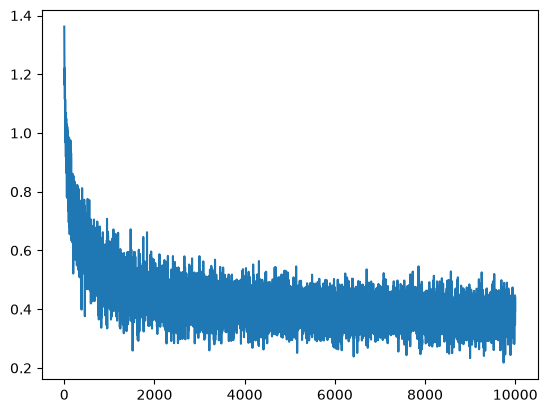

In [768]:
# by ploting learning rate to loss, we can find a good learning
# rate when the loss is stabilizing, it seens to be 0.1

# demo lr, at 0.1 loss starts to diverge
# plt.plot(lri,lossi)

# solution lr
plt.plot(stepi,lossi)

# loss function at 1000 seems to stabilize with lr=0.1

# can train model by 0.1lr by few more steps

## Evaluate on train / dev / test

Run each *entire* split through the model at once (no minibatching) to get a stable loss estimate. Comparing train vs. dev loss is the overfitting check — if train loss is much lower than dev loss, the model has started memorizing training names instead of learning general patterns. (The `# (32, 3, 2)` shape comments in these three cells are stale — with the current `embbed_d=10` the real `emb` shape is `(N, 3, 10)`.)

In [769]:
# training loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3908, grad_fn=<NllLossBackward0>)

In [770]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3978, grad_fn=<NllLossBackward0>)

In [771]:
# test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.4030, grad_fn=<NllLossBackward0>)

## Visualize the learned embeddings

Plot the first two dimensions of `C` (the embedding table) for every character. Characters that behave similarly in names tend to cluster together once training has shaped `C` - the same idea presented in word2vec, but for single characters instead of words.

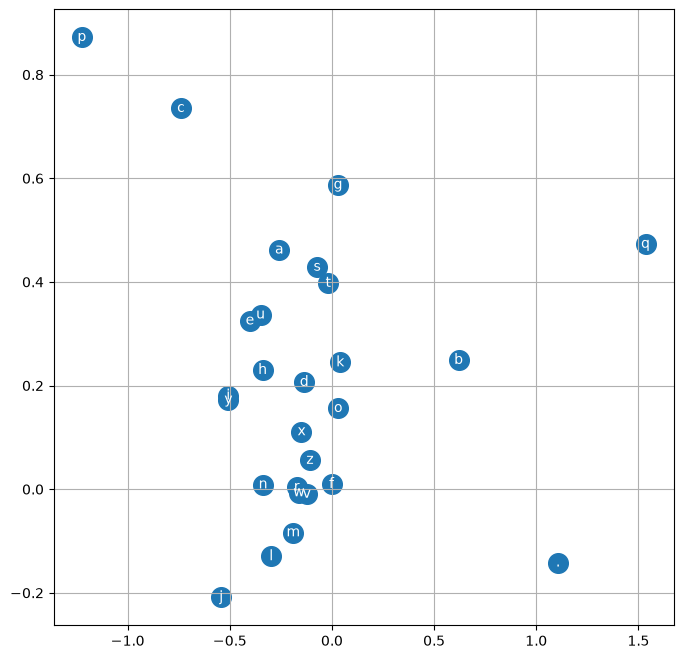

In [772]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

## Sample names from the trained model

Generate new names character-by-character: start from an all-`.` context, run it through the network to get a probability distribution over the next character, sample one (`torch.multinomial`, not argmax — so outputs vary run to run), slide it into the context, and repeat until a `.` (end-of-name) gets sampled.

In [778]:
# sample from the model
#g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

jasiahtlre.
krierad.
dlez.
lonw.
quesln.
marind.
kurah.
kathieeh.
dlis.
dedia.
kyerynxe.
zren.
kyledar.
cce.
faire.
jayzir.
akiir.
lea.
zhie.
shr.
